In [1]:
import pandas as pd
from datetime import datetime

import matplotlib.pyplot as plt

In [2]:
path = r'../11_how to check nft wallet transactions/doodles_transfers_last_6_months.csv'

# read csv from path
doodles_transfers_last_6_months = pd.read_csv(path)

# Convert 'timeStamp' to datetime
doodles_transfers_last_6_months['timeStamp'] = pd.to_datetime(doodles_transfers_last_6_months['timeStamp'], unit='s')

# doodles_transfers_last_6_months.head(5)

In [3]:
doodles_transfers_last_6_months.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7397 entries, 0 to 7396
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   blockNumber        7397 non-null   int64         
 1   timeStamp          7397 non-null   datetime64[ns]
 2   hash               7397 non-null   object        
 3   nonce              7397 non-null   int64         
 4   blockHash          7397 non-null   object        
 5   from               7397 non-null   object        
 6   contractAddress    7397 non-null   object        
 7   to                 7397 non-null   object        
 8   tokenID            7397 non-null   int64         
 9   tokenName          7397 non-null   object        
 10  tokenSymbol        7397 non-null   object        
 11  tokenDecimal       7397 non-null   int64         
 12  transactionIndex   7397 non-null   int64         
 13  gas                7397 non-null   int64         
 14  gasPrice

In [4]:
# doodles_transfers_last_6_months.head()
doodles_transfers_last_6_months.tail()

,blockNumber,timeStamp,hash,nonce,blockHash,from,contractAddress,to,tokenID,tokenName,...,tokenDecimal,transactionIndex,gas,gasPrice,gasUsed,cumulativeGasUsed,input,methodId,functionName,confirmations
7392,23567687,2025-10-13 08:45:11,0x1d6b196662d78ea81c4780b60b334cc464a7bdfb09e1...,2972,0xd0e82af0f4e5afc01fb66e79d302cb146f3d2d94e5b2...,0x3772fad0e4de82f27620c946e7f52946332ea02c,0x8a90cab2b38dba80c64b7734e58ee1db38b8992e,0x49a616dfc3a8980497807b2320084be1350601a1,879,Doodles,...,0,77,210178,7955790195,196867,12475113,deprecated,0xda815cb5,"takeBidSingle(tuple inputs,bytes oracleSignature)",1287367
7393,23567687,2025-10-13 08:45:11,0xcefa870f56ee94a6d91a8ed1a5742c9db283494e329b...,6269,0xd0e82af0f4e5afc01fb66e79d302cb146f3d2d94e5b2...,0xeb79f3b9836e14678abdb862aabfc171341b3199,0x8a90cab2b38dba80c64b7734e58ee1db38b8992e,0x1ea27bce786a81022dfc156059771e8d3279a9a6,4036,Doodles,...,0,67,201549,35355790195,182567,10669151,deprecated,0xda815cb5,"takeBidSingle(tuple inputs,bytes oracleSignature)",1287367
7394,23567686,2025-10-13 08:44:59,0x8be3ad3b7213493f4fe2feb233f36dd971d64f5d40eb...,126,0xe760cde76d5200466a2f0ac41b6397d33dc0d172aca0...,0x6d60d0e5afa322affb5792230ee800d4d656fef6,0x8a90cab2b38dba80c64b7734e58ee1db38b8992e,0x5a8e4ec3c2fe1f3369d0704acbad5cb34d00caa1,1730,Doodles,...,0,23,1612539,503787749,1534012,7046323,deprecated,0x87201b41,fulfillAvailableAdvancedOrders(tuple[] advance...,1287368
7395,23567685,2025-10-13 08:44:47,0xb2a015d0fca425dc99ee8e367ed1534413e2914b433a...,1160,0x7071c37c9ccd760a10e28dd8afb85f3ca66c052d9432...,0x4263eb5638e8bf83af72ccde9b7c50feacc4fe4a,0x8a90cab2b38dba80c64b7734e58ee1db38b8992e,0x29469395eaf6f95920e59f858042f0e28d98a20b,5905,Doodles,...,0,14,215978,1859424663,202588,5077965,deprecated,0xe263967e,"borrow(tuple offer,bytes signature,uint256 loa...",1287369
7396,23567680,2025-10-13 08:43:47,0x1982b6d57d95208ea4e8d5eecc64d9bbb9aded692c26...,124,0x51365e0f6507518d02d1b425dc13ce7202a2691b0fdc...,0x6d60d0e5afa322affb5792230ee800d4d656fef6,0x8a90cab2b38dba80c64b7734e58ee1db38b8992e,0x4263eb5638e8bf83af72ccde9b7c50feacc4fe4a,5905,Doodles,...,0,87,326055,493636386,313260,8785735,deprecated,0xf2d12b12,"matchAdvancedOrders(tuple[] ,tuple[] ,tuple[] ...",1287374


In [5]:
# tokenName unique values
unique_token_names = doodles_transfers_last_6_months['tokenName'].unique()
print(unique_token_names)         

['Doodles']


In [6]:
# timeStamp min and max values
min_timestamp = doodles_transfers_last_6_months['timeStamp'].min()
max_timestamp = doodles_transfers_last_6_months['timeStamp'].max()
print(f"Min timestamp: {min_timestamp}")
print(f"Max timestamp: {max_timestamp}")

Min timestamp: 2025-10-13 08:43:47
Max timestamp: 2026-04-11 02:37:59


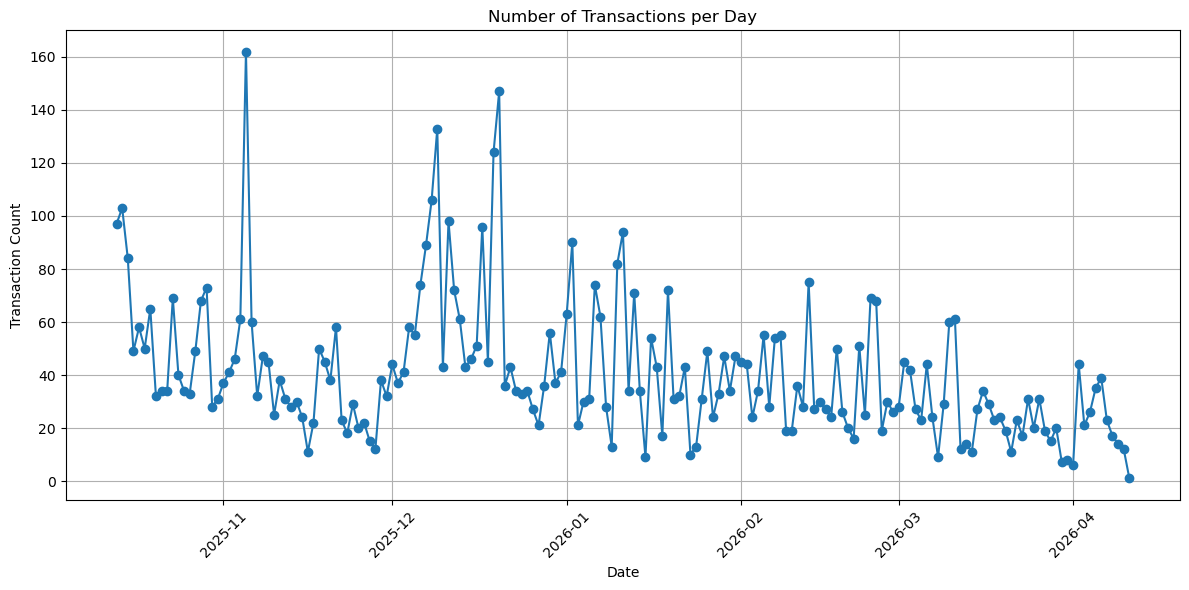

In [7]:
# divide timestamp into date and time
# group by date and count the number of transactions per day
grouped_by_date = doodles_transfers_last_6_months.groupby(doodles_transfers_last_6_months['timeStamp'].dt.date).size().reset_index(name='transaction_count')

# plot the number of transactions per day
plt.figure(figsize=(12, 6))
plt.plot(grouped_by_date['timeStamp'], grouped_by_date['transaction_count'], marker='o')
plt.title('Number of Transactions per Day')
plt.xlabel('Date')  
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [8]:
# group by timeStamp and count tokenID
grouped_data = doodles_transfers_last_6_months.groupby('timeStamp')['tokenID'].count().reset_index()
grouped_data.columns = ['timeStamp', 'tokenID_count']

grouped_data.head()

,timeStamp,tokenID_count
0,2025-10-13 08:43:47,1
1,2025-10-13 08:44:47,1
2,2025-10-13 08:44:59,1
3,2025-10-13 08:45:11,2
4,2025-10-13 08:45:23,2


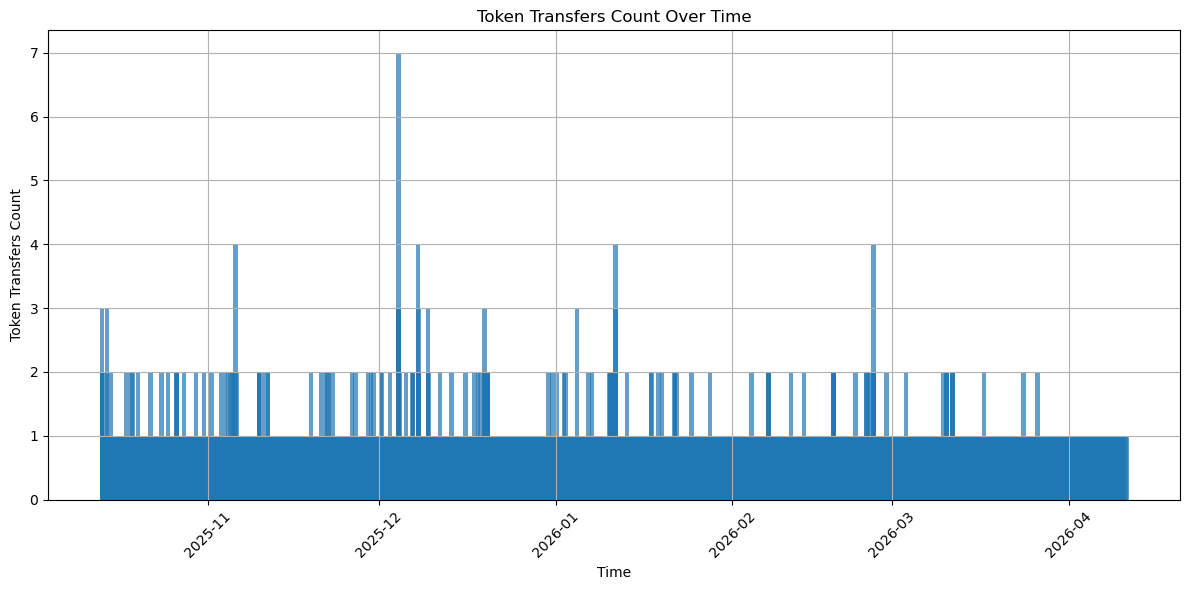

In [9]:
# plot the data
plt.figure(figsize=(12, 6))
plt.bar(grouped_data['timeStamp'], grouped_data['tokenID_count'], alpha=0.7)
plt.title('Token Transfers Count Over Time')
plt.xlabel('Time')
plt.ylabel('Token Transfers Count')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [10]:
# transactions to whale wallets to identify potential whale activity

whales_path = r'../11_how to check nft wallet transactions/Doodles.xlsx'
whales_df = pd.read_excel(whales_path)

# Display the first few rows of the whales DataFrame
whales_df.head()

,wallet
0,0xAd71Ad65d9a7E238F5d6145c92E2eEB00b6C3b1b
1,0x958ab8695f33Cc5BeccBCb90B5A6c11B5f705e39
2,0xA71365a3A7f4f6a9F4AC18d65Ab338E0C9708830
3,0x0C37f1FC90BF56387B59615508bbd975D448856F
4,0x9b37BC499De5e675063695211618F3Cd64A1B9Fc


In [11]:
# Creare una colonna whales_count per identificare transazioni verso whale wallets
# Se doodles_transfers_last_6_months.to è uguale a un wallet in whales_df.wallet, 
# allora whales_count = 1, altrimenti 0

# Convertire i wallet addresses a lowercase per un confronto case-insensitive
whales_wallets = whales_df['wallet'].str.lower().tolist()
doodles_transfers_last_6_months['to_lower'] = doodles_transfers_last_6_months['to'].str.lower()

# Creare la colonna whales_count: 1 se il wallet di destinazione è un whale, 0 altrimenti
doodles_transfers_last_6_months['whales_count'] = doodles_transfers_last_6_months['to_lower'].isin(whales_wallets).astype(int)

# Rimuovere la colonna temporanea to_lower
doodles_transfers_last_6_months.drop(columns=['to_lower'], inplace=True)

# Mostrare le statistiche dei whale transfers
whale_transfers_count = doodles_transfers_last_6_months['whales_count'].sum()
total_transfers = len(doodles_transfers_last_6_months)

print(f"Total transfers: {total_transfers}")
print(f"Transfers to whale wallets: {whale_transfers_count}")
print(f"Percentage of transfers to whales: {whale_transfers_count/total_transfers*100:.2f}%")

# Mostrare le prime righe con la nuova colonna
doodles_transfers_last_6_months[['from', 'to', 'tokenID', 'whales_count']].head(10)

Total transfers: 7397
Transfers to whale wallets: 591
Percentage of transfers to whales: 7.99%


,from,to,tokenID,whales_count
0,0xccf8b496e7cbe1a834912f1c400629a120b45a38,0x97f9ef6b302a926385b7abea4bcabe9f2fb1b412,6158,0
1,0x620b70123fb810f6c653da7644b5dd0b6312e4d8,0xc1033ebdbf17e1a350d18196035c26090eaac708,1700,0
2,0x05f122d0df4de17a9bbfa7f15448e972f587e041,0xdeda1e33769c1e2978aa2e11f929876c9eb2b71a,944,0
3,0x4bc5fa56f2931e7a37417fa55dda71e4b7c2f2a3,0x2ae3e46290ade43593eabd15642ebd67157f5351,5528,0
4,0x6c414f94194e3c0ff752a1d24d0dcc577f418193,0x3375d4fe10af414eeb96229382d25c0e19c00985,6315,0
5,0x12975180f91289c660dbf89bd367f6b8eaf50860,0x05f122d0df4de17a9bbfa7f15448e972f587e041,944,0
6,0x12975180f91289c660dbf89bd367f6b8eaf50860,0xccf8b496e7cbe1a834912f1c400629a120b45a38,6158,0
7,0x6ce42d8b2a202e206051bc09dbaafd1fed24d044,0x29469395eaf6f95920e59f858042f0e28d98a20b,9327,0
8,0xf41b389e0c1950dc0b16c9498eae77131cc08a56,0x6ce42d8b2a202e206051bc09dbaafd1fed24d044,9327,1
9,0x4d108fc1d0cd7c14d85996599d6c3215a92a5c47,0xb40ff1ca580090b386048228ae7140b0dde7f1c5,73,0


In [12]:
doodles_transfers_last_6_months.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7397 entries, 0 to 7396
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   blockNumber        7397 non-null   int64         
 1   timeStamp          7397 non-null   datetime64[ns]
 2   hash               7397 non-null   object        
 3   nonce              7397 non-null   int64         
 4   blockHash          7397 non-null   object        
 5   from               7397 non-null   object        
 6   contractAddress    7397 non-null   object        
 7   to                 7397 non-null   object        
 8   tokenID            7397 non-null   int64         
 9   tokenName          7397 non-null   object        
 10  tokenSymbol        7397 non-null   object        
 11  tokenDecimal       7397 non-null   int64         
 12  transactionIndex   7397 non-null   int64         
 13  gas                7397 non-null   int64         
 14  gasPrice

In [13]:
# group by date of timeStamp and sum() whales_count
grouped_whales_buys = doodles_transfers_last_6_months.groupby(doodles_transfers_last_6_months['timeStamp'].dt.date)['whales_count'].sum().reset_index()
grouped_whales_buys.columns = ['date', 'whales_count']

grouped_whales_buys.head()

,date,whales_count
0,2025-10-13,0
1,2025-10-14,5
2,2025-10-15,1
3,2025-10-16,2
4,2025-10-17,0


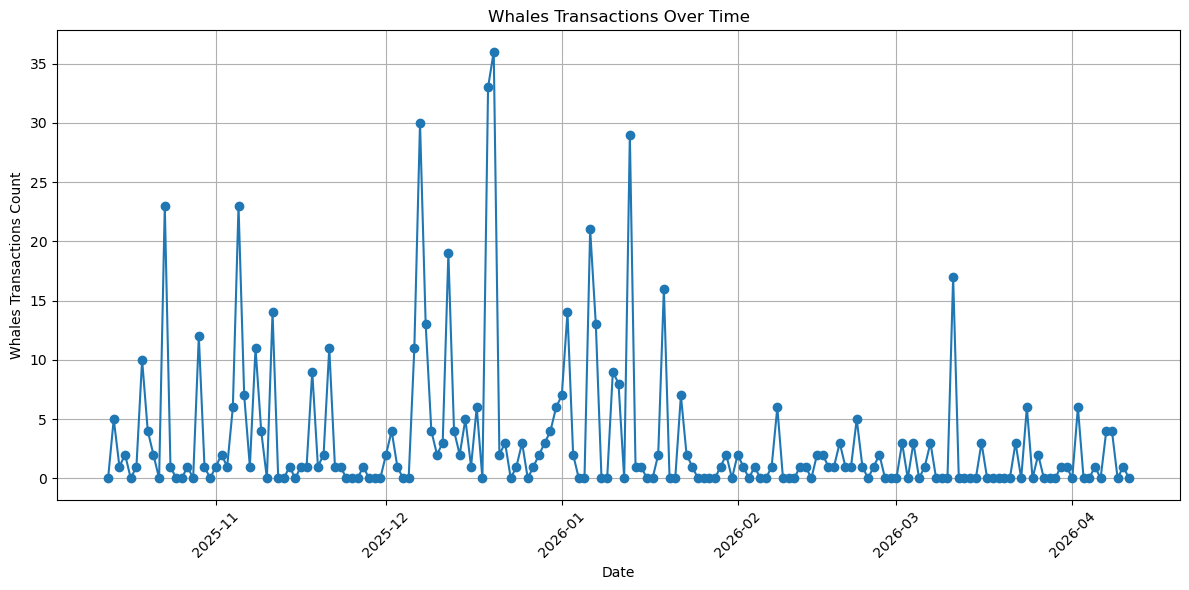

In [14]:
# plot the whales_count over time
plt.figure(figsize=(12, 6))
plt.plot(grouped_whales_buys['date'], grouped_whales_buys['whales_count'], marker='o')
plt.title('Whales Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Whales Transactions Count')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [15]:
# merge grouped_by_date with grouped_whales_buys on date
merged_data = pd.merge(grouped_by_date, grouped_whales_buys, left_on='timeStamp', right_on='date', how='left')
merged_data.rename(columns={'transaction_count': 'total_transactions', 'whales_count': 'whales_transactions'}, inplace=True)

# drop date
merged_data.drop(columns=['date'], inplace=True)

# set timeStamp as index
merged_data.set_index('timeStamp', inplace=True)

merged_data.head()

,total_transactions,whales_transactions
timeStamp,,
2025-10-13,97,0
2025-10-14,103,5
2025-10-15,84,1
2025-10-16,49,2
2025-10-17,58,0


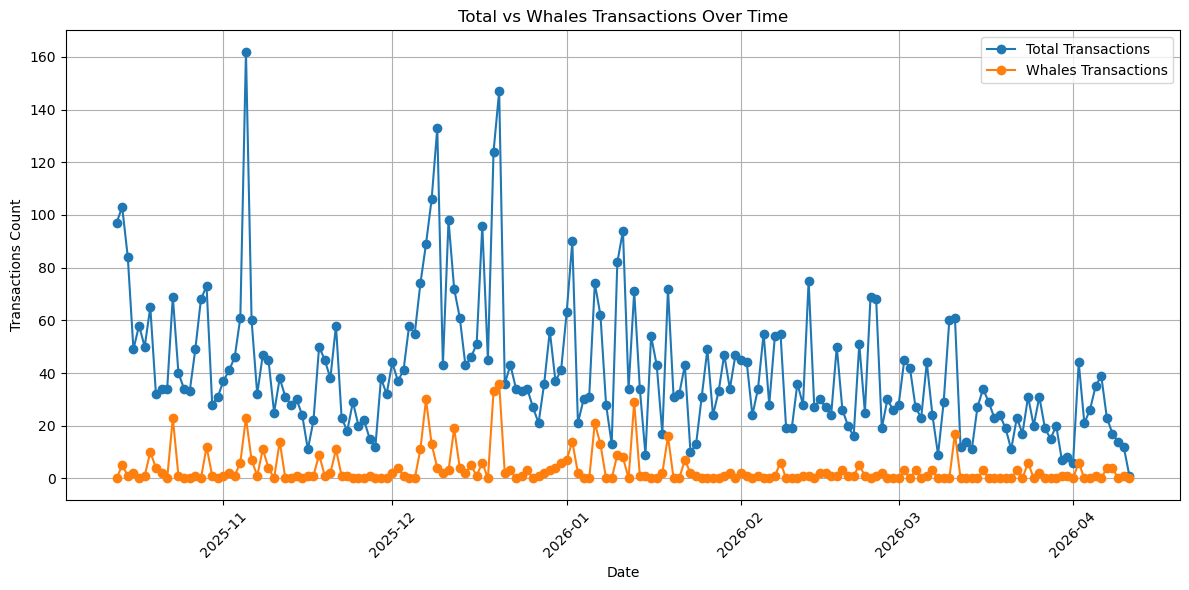

In [16]:
# plot total_transactions and whales_transactions
plt.figure(figsize=(12, 6))
plt.plot(merged_data.index, merged_data['total_transactions'], label='Total Transactions', marker='o')
plt.plot(merged_data.index, merged_data['whales_transactions'], label='Whales Transactions', marker='o')
plt.title('Total vs Whales Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Transactions Count')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()